# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**刘佳琦**  
第5天专题（A/B/C/D/E）：**B（投诉与服务体验）**

本Notebook完成4张独立图、1张2×2综合图和1份图表清单。所有图表均从第4天清洗数据和第5天分析结果出发，并遵循“观察—证据—边界”的解释结构。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)

    def Markdown(text):
        return text


STUDENT_ID = "刘佳琦"
TOPIC = "B"


pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# 优先使用常见中文字体；兼容Mac、Windows和Linux。
from matplotlib import font_manager

font_paths = [
    Path("/System/Library/Fonts/PingFang.ttc"),
    Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
    Path("/usr/share/fonts/truetype/arphic/uming.ttc"),
]
for font_path in font_paths:
    if font_path.exists():
        try:
            font_manager.fontManager.addfont(str(font_path))
        except Exception:
            pass

font_candidates = [
    "PingFang SC", "Microsoft YaHei", "SimHei",
    "Noto Sans CJK JP", "AR PL UMing CN",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
selected_font = "DejaVu Sans"
for font_name in font_candidates:
    try:
        font_manager.findfont(font_name, fallback_to_default=False)
        selected_font = font_name
        break
    except Exception:
        continue

plt.rcParams["font.sans-serif"] = [selected_font, "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
print("绘图字体：", selected_font)


def find_workspace_root(start=None):
    """从当前目录向上寻找课程项目根目录。"""
    start = Path.cwd() if start is None else Path(start)

    for candidate in [start, *start.parents]:
        cleaned_path = (
            candidate
            / "output"
            / "day04_project"
            / "ecommerce_customer_cleaned.csv"
        )
        if cleaned_path.exists():
            return candidate

    raise FileNotFoundError(
        "未找到第4天清洗数据。请先运行Day04，并确认存在："
        "output/day04_project/ecommerce_customer_cleaned.csv"
    )


def percent_with_n(rate, n):
    """生成“百分比 + 样本量”标签。"""
    return f"{rate:.1%}\n(n={int(n):,})"


def correlation_description(value):
    """将相关系数转成有边界的文字描述。"""
    abs_value = abs(float(value))
    if abs_value < 0.10:
        level = "几乎没有线性关系"
    elif abs_value < 0.30:
        level = "较弱线性关系"
    elif abs_value < 0.50:
        level = "中等线性关系"
    else:
        level = "较强线性关系"

    direction = "正向" if value > 0 else "负向" if value < 0 else "无方向"
    return f"{level}（{direction}）"


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


assert STUDENT_ID.strip(), "学生信息不能为空"
assert TOPIC in {"A", "B", "C", "D", "E"}, "TOPIC只能是A/B/C/D/E"

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输入：", DATA_PATH.relative_to(ROOT))
print("输出：", OUTPUT_DIR.relative_to(ROOT))


绘图字体： Arial Unicode MS
学生： 刘佳琦
专题： B
输入： output/day04_project/ecommerce_customer_cleaned.csv
输出： output/day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标,数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用次数,1.72
6,平均返现,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,Complain,用户数,流失人数,流失率,平均满意度,平均订单数,平均返现
0,0,4026,440,0.11,3.09,3.00,177.21
1,1,1604,508,0.32,3.00,2.86,177.26


,Complain,TenureGroup,用户数,流失人数,流失率,平均订单数,平均满意度,样本提示
0,1,新用户(≤3个月),522,345,0.66,2.55,3.07,可观察
1,0,新用户(≤3个月),1038,308,0.30,2.20,3.23,可观察
2,1,成长期(4-6个月),137,30,0.22,3.03,2.75,可观察
3,1,稳定期(7-12个月),406,81,0.20,2.67,3.02,可观察
4,1,忠诚期(13-24个月),414,52,0.13,3.35,2.91,可观察


检查点1A通过：输入文件有效


In [3]:
business_questions = {
    "category_bar": (
        "投诉用户与未投诉用户的流失率是否存在差异，"
        "各组样本量分别是多少？"
    ),
    "behavior_scatter": (
        "用户订单次数与返现金额之间呈现怎样的关系，"
        "流失用户和未流失用户的分布是否不同？"
    ),
    "ordered_line": (
        "随着满意度评分从1分提高到5分，"
        "各评分阶段的流失率如何变化？"
    ),
    "composition_chart": (
        "当前样本中流失用户和未流失用户分别占多大比例？"
    ),
}

chart_reasons = {
    "category_bar": (
        "投诉状态是离散类别，柱状图适合比较两组流失率；"
        "同时在标签中标注用户数，避免只看比例忽略样本量。"
    ),
    "behavior_scatter": (
        "订单次数和返现金额都是用户级数值字段，散点图能够展示"
        "两变量的联合分布、聚集、重叠与候选异常点。"
    ),
    "ordered_line": (
        "满意度评分1至5具有明确顺序，折线图用于比较有序评分阶段；"
        "本图不是时间趋势图。"
    ),
    "composition_chart": (
        "流失状态只有两个类别，适合使用环形图展示整体构成；"
        "环形图用于表达占比，不用于精细比较多组差异。"
    ),
}

assert all(text.strip() for text in business_questions.values())
assert all(text.strip() for text in chart_reasons.values())

display(pd.DataFrame({
    "图表": business_questions.keys(),
    "业务问题": business_questions.values(),
    "选择理由": chart_reasons.values(),
}))
print("检查点1B通过：业务问题和选择理由已填写")


,图表,业务问题,选择理由
0,category_bar,投诉用户与未投诉用户的流失率是否存在差异，各组样本量分别是多少？,投诉状态是离散类别，柱状图适合比较两组流失率；同时在标签中标注用户数，避免只看比例忽略样本量。
1,behavior_scatter,用户订单次数与返现金额之间呈现怎样的关系，流失用户和未流失用户的分布是否不同？,订单次数和返现金额都是用户级数值字段，散点图能够展示两变量的联合分布、聚集、重叠与候选异常点。
2,ordered_line,随着满意度评分从1分提高到5分，各评分阶段的流失率如何变化？,满意度评分1至5具有明确顺序，折线图用于比较有序评分阶段；本图不是时间趋势图。
3,composition_chart,当前样本中流失用户和未流失用户分别占多大比例？,流失状态只有两个类别，适合使用环形图展示整体构成；环形图用于表达占比，不用于精细比较多组差异。


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# 第5天专题B：投诉与服务体验
category_field = "Complain"

category_summary = (
    df.groupby(category_field, dropna=False)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失人数=("Churn", "sum"),
        流失率=("Churn", "mean"),
        平均满意度=("SatisfactionScore", "mean"),
        平均订单数=("OrderCount", "mean"),
    )
    .reset_index()
    .sort_values(category_field)
    .reset_index(drop=True)
)

category_summary["投诉状态"] = (
    category_summary[category_field]
    .map({0: "未投诉", 1: "已投诉"})
    .fillna(category_summary[category_field].astype(str))
)

assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame)
assert {category_field, "用户数", "流失率"}.issubset(category_summary.columns)
assert category_summary["用户数"].sum() == len(df)

# 与第5天专题B的单维分析结果核对
day05_required = {"Complain", "用户数", "流失率"}
if day05_required.issubset(segment_analysis.columns):
    reconciliation = category_summary[
        ["Complain", "用户数", "流失率"]
    ].merge(
        segment_analysis[["Complain", "用户数", "流失率"]],
        on="Complain",
        suffixes=("_day06", "_day05"),
        how="inner",
    )
    assert len(reconciliation) == len(category_summary)
    assert (
        reconciliation["用户数_day06"].to_numpy()
        == reconciliation["用户数_day05"].to_numpy()
    ).all()
    assert np.allclose(
        reconciliation["流失率_day06"],
        reconciliation["流失率_day05"],
    )
    print("已核对：Day06投诉分组结果与Day05 segment_analysis一致")

display(category_summary)


已核对：Day06投诉分组结果与Day05 segment_analysis一致


,Complain,用户数,流失人数,流失率,平均满意度,平均订单数,投诉状态
0,0,4026,440,0.11,3.09,3.00,未投诉
1,1,1604,508,0.32,3.00,2.86,已投诉


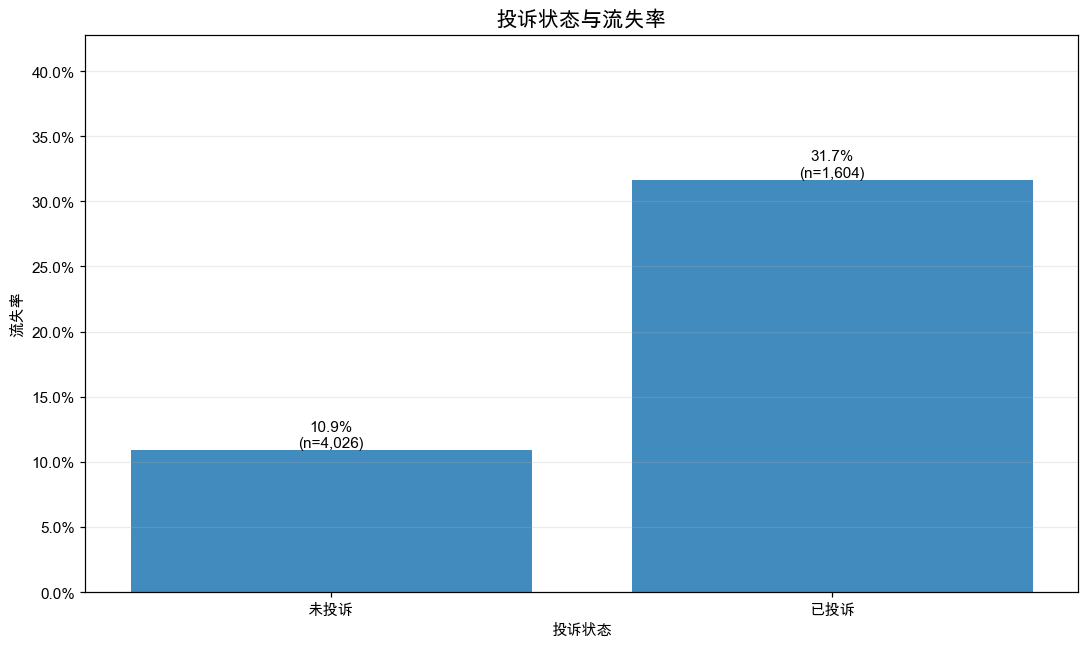

已输出： output/day06_visualization/01_category_bar.png


In [5]:
def draw_category_bar(ax, compact=False):
    labels = category_summary["投诉状态"]
    rates = category_summary["流失率"]
    counts = category_summary["用户数"]

    bars = ax.bar(labels, rates, alpha=0.85)

    for bar, rate, n in zip(bars, rates, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            percent_with_n(rate, n),
            ha="center",
            va="bottom",
            fontsize=9 if compact else 10,
        )

    ax.set_title(
        "投诉状态与流失率",
        fontsize=11 if compact else 14,
        fontweight="bold",
    )
    ax.set_xlabel("投诉状态")
    ax.set_ylabel("流失率")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    upper = max(float(rates.max()) * 1.35, 0.10)
    ax.set_ylim(0, min(1.0, upper))
    ax.grid(axis="y", alpha=0.25)


fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
draw_category_bar(ax_bar)
fig_bar.tight_layout()

bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_bar)

assert bar_path.exists() and bar_path.stat().st_size > 0
print("已输出：", bar_path.relative_to(ROOT))


In [6]:
bar_high = category_summary.loc[category_summary["流失率"].idxmax()]
bar_low = category_summary.loc[category_summary["流失率"].idxmin()]
bar_gap = float(bar_high["流失率"] - bar_low["流失率"])

display(Markdown(
    f"""
### 柱状图结论

- **观察：** `{bar_high["投诉状态"]}`组的流失率高于`{bar_low["投诉状态"]}`组。
- **证据：** `{bar_high["投诉状态"]}`组有{int(bar_high["用户数"]):,}名用户，
  流失率为{bar_high["流失率"]:.2%}；`{bar_low["投诉状态"]}`组有
  {int(bar_low["用户数"]):,}名用户，流失率为{bar_low["流失率"]:.2%}，
  两组相差{bar_gap:.2%}（约{bar_gap * 100:.2f}个百分点）。
- **边界：** 该图只说明当前样本中投诉状态与流失存在分组差异，
  不能证明投诉直接导致流失；还需结合投诉类型、发生时间和处理结果验证。
"""
))



### 柱状图结论

- **观察：** `已投诉`组的流失率高于`未投诉`组。
- **证据：** `已投诉`组有1,604名用户，
  流失率为31.67%；`未投诉`组有
  4,026名用户，流失率为10.93%，
  两组相差20.74%（约20.74个百分点）。
- **边界：** 该图只说明当前样本中投诉状态与流失存在分组差异，
  不能证明投诉直接导致流失；还需结合投诉类型、发生时间和处理结果验证。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


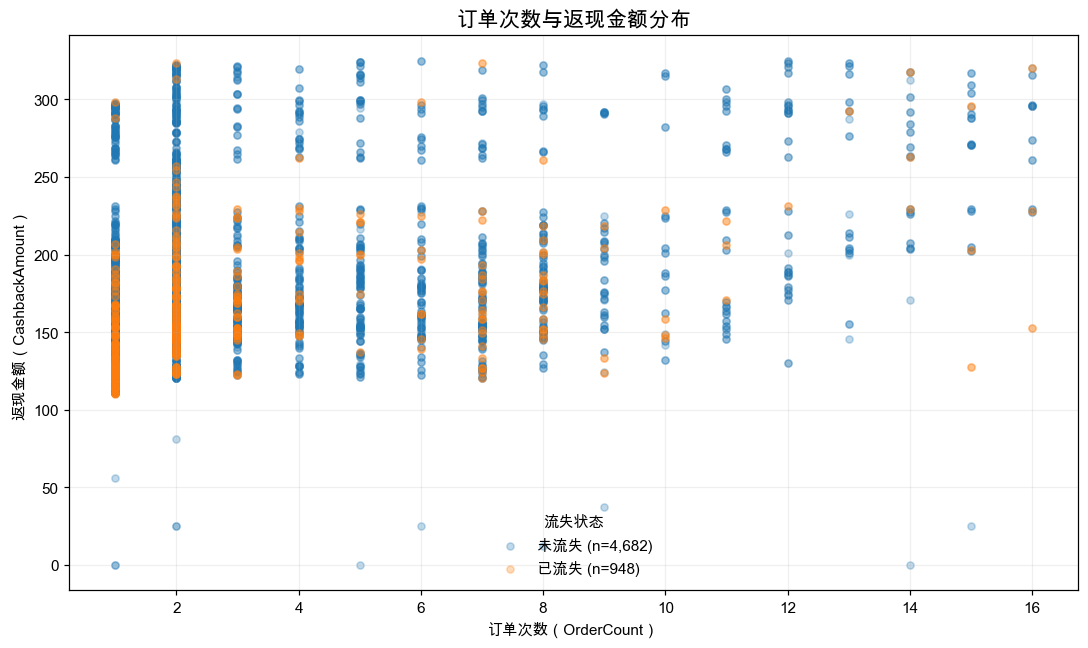

已输出： output/day06_visualization/02_behavior_scatter.png


In [7]:
# 一行代表一名用户
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])


def draw_behavior_scatter(ax, compact=False):
    for churn_value, label in [(0, "未流失"), (1, "已流失")]:
        subset = df.loc[
            df["Churn"].eq(churn_value),
            [x_field, y_field],
        ].dropna()

        ax.scatter(
            subset[x_field],
            subset[y_field],
            alpha=0.28,
            s=18 if compact else 22,
            label=f"{label} (n={len(subset):,})",
        )

    ax.set_title(
        "订单次数与返现金额分布",
        fontsize=11 if compact else 14,
        fontweight="bold",
    )
    ax.set_xlabel("订单次数（OrderCount）")
    ax.set_ylabel("返现金额（CashbackAmount）")
    ax.grid(alpha=0.20)
    ax.legend(title="流失状态", frameon=False)


fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))
draw_behavior_scatter(ax_scatter)
fig_scatter.tight_layout()

scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_scatter)

assert scatter_path.exists() and scatter_path.stat().st_size > 0
print("已输出：", scatter_path.relative_to(ROOT))


In [8]:
scatter_data = df[[x_field, y_field, "Churn"]].dropna()
scatter_corr = float(scatter_data[[x_field, y_field]].corr().iloc[0, 1])

scatter_group_stats = (
    scatter_data.groupby("Churn")
    .agg(
        用户数=("Churn", "size"),
        订单次数中位数=(x_field, "median"),
        返现金额中位数=(y_field, "median"),
    )
)

not_churned = scatter_group_stats.loc[0]
churned = scatter_group_stats.loc[1]

display(Markdown(
    f"""
### 散点图结论

- **观察：** 订单次数与返现金额呈{correlation_description(scatter_corr)}；
  两类用户在图中有较多重叠，仅凭这两个字段难以清晰区分流失状态。
- **证据：** 全体用户的Pearson相关系数为`r={scatter_corr:.3f}`。
  未流失用户的订单次数中位数为{not_churned["订单次数中位数"]:.2f}、
  返现金额中位数为{not_churned["返现金额中位数"]:.2f}；
  流失用户对应中位数为{churned["订单次数中位数"]:.2f}和
  {churned["返现金额中位数"]:.2f}。
- **边界：** 散点关系不等于因果关系，返现金额也不是销售额或GMV；
  图中极端点只能作为候选异常或特殊用户进一步核查，不能自动删除。
"""
))



### 散点图结论

- **观察：** 订单次数与返现金额呈中等线性关系（正向）；
  两类用户在图中有较多重叠，仅凭这两个字段难以清晰区分流失状态。
- **证据：** 全体用户的Pearson相关系数为`r=0.322`。
  未流失用户的订单次数中位数为2.00、
  返现金额中位数为166.12；
  流失用户对应中位数为2.00和
  149.66。
- **边界：** 散点关系不等于因果关系，返现金额也不是销售额或GMV；
  图中极端点只能作为候选异常或特殊用户进一步核查，不能自动删除。


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [9]:
# 满意度评分1—5具有明确顺序，适合作“有序阶段比较”
ordered_field = "SatisfactionScore"

ordered_summary = (
    df.groupby(ordered_field, dropna=False)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失人数=("Churn", "sum"),
        流失率=("Churn", "mean"),
        平均订单数=("OrderCount", "mean"),
    )
    .reset_index()
    .sort_values(ordered_field)
    .reset_index(drop=True)
)

assert ordered_field in {"TenureGroup", "SatisfactionScore"}
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数", "流失率"}.issubset(ordered_summary.columns)
assert ordered_summary["用户数"].sum() == len(df)

display(ordered_summary)


,SatisfactionScore,用户数,流失人数,流失率,平均订单数
0,1,1164,134,0.12,2.92
1,2,586,74,0.13,2.94
2,3,1698,292,0.17,2.91
3,4,1074,184,0.17,2.95
4,5,1108,264,0.24,3.10


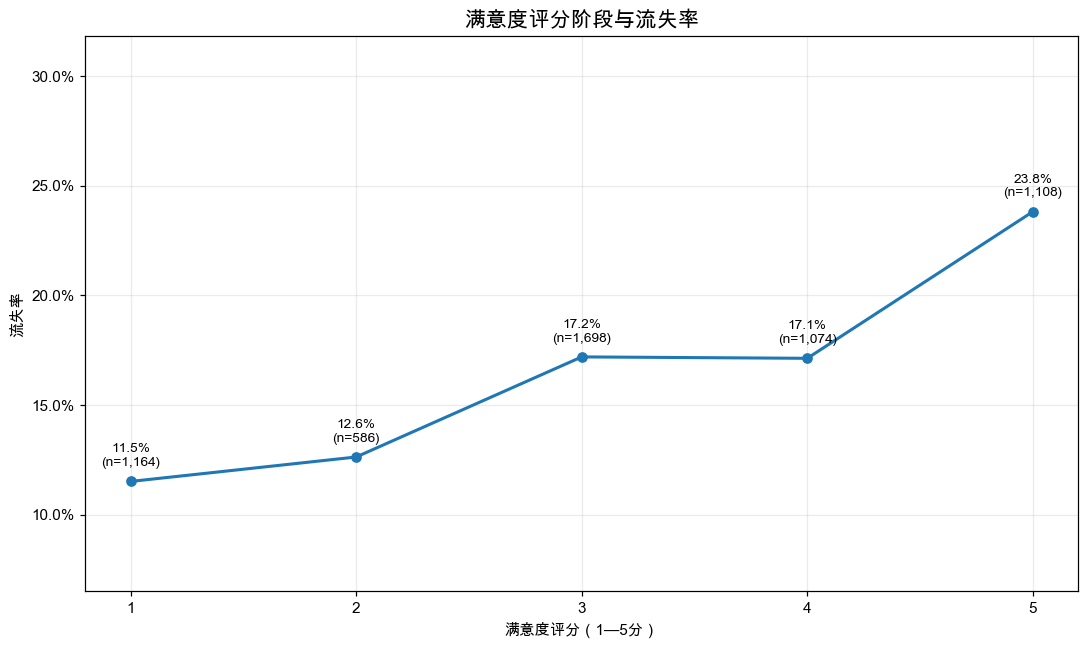

已输出： output/day06_visualization/03_ordered_line.png


In [12]:
def draw_ordered_line(ax, compact=False):
    x_values = ordered_summary[ordered_field]
    rates = ordered_summary["流失率"]
    counts = ordered_summary["用户数"]

    ax.plot(x_values, rates, marker="o", linewidth=2)

    for x, rate, n in zip(x_values, rates, counts):
        ax.annotate(
            percent_with_n(rate, n),
            xy=(x, rate),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8 if compact else 9,
        )

    ax.set_title(
        "满意度评分阶段与流失率",
        fontsize=11 if compact else 14,
        fontweight="bold",
    )
    ax.set_xlabel("满意度评分（1—5分）")
    ax.set_ylabel("流失率")
    ax.set_xticks(x_values)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    lower = max(0.0, float(rates.min()) - 0.05)
    upper = min(1.0, float(rates.max()) + 0.08)
    if upper <= lower:
        upper = min(1.0, lower + 0.10)
    ax.set_ylim(lower, upper)
    ax.grid(alpha=0.25)


fig_line, ax_line = plt.subplots(figsize=(10, 6))
draw_ordered_line(ax_line)
fig_line.tight_layout()

line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_line)

assert line_path.exists() and line_path.stat().st_size > 0
print("已输出：", line_path.relative_to(ROOT))


In [11]:
line_high = ordered_summary.loc[ordered_summary["流失率"].idxmax()]
line_low = ordered_summary.loc[ordered_summary["流失率"].idxmin()]
line_gap = float(line_high["流失率"] - line_low["流失率"])

display(Markdown(
    f"""
### 折线图结论

- **观察：** 流失率没有随着满意度评分单调上升或下降；
  评分{int(line_high[ordered_field])}分阶段最高，评分
  {int(line_low[ordered_field])}分阶段最低。
- **证据：** {int(line_high[ordered_field])}分组有
  {int(line_high["用户数"]):,}名用户，流失率为{line_high["流失率"]:.2%}；
  {int(line_low[ordered_field])}分组有{int(line_low["用户数"]):,}名用户，
  流失率为{line_low["流失率"]:.2%}，相差{line_gap * 100:.2f}个百分点。
- **边界：** 这是满意度评分的有序阶段比较，不是月度、年度或历史时间趋势；
  评分与流失的关系还可能受到用户生命周期、投诉和订单行为等因素影响。
"""
))



### 折线图结论

- **观察：** 流失率没有随着满意度评分单调上升或下降；
  评分5分阶段最高，评分
  1分阶段最低。
- **证据：** 5分组有
  1,108名用户，流失率为23.83%；
  1分组有1,164名用户，
  流失率为11.51%，相差12.31个百分点。
- **边界：** 这是满意度评分的有序阶段比较，不是月度、年度或历史时间趋势；
  评分与流失的关系还可能受到用户生命周期、投诉和订单行为等因素影响。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [13]:
composition_field = "Churn"

composition_summary = (
    df.groupby(composition_field, dropna=False)
    .agg(用户数=("CustomerID", "nunique"))
    .reset_index()
    .sort_values(composition_field)
    .reset_index(drop=True)
)

composition_summary["占比"] = (
    composition_summary["用户数"] / composition_summary["用户数"].sum()
)
composition_summary["流失状态"] = (
    composition_summary[composition_field]
    .map({0: "未流失", 1: "已流失"})
    .fillna(composition_summary[composition_field].astype(str))
)

assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0)

display(composition_summary)


,Churn,用户数,占比,流失状态
0,0,4682,0.83,未流失
1,1,948,0.17,已流失


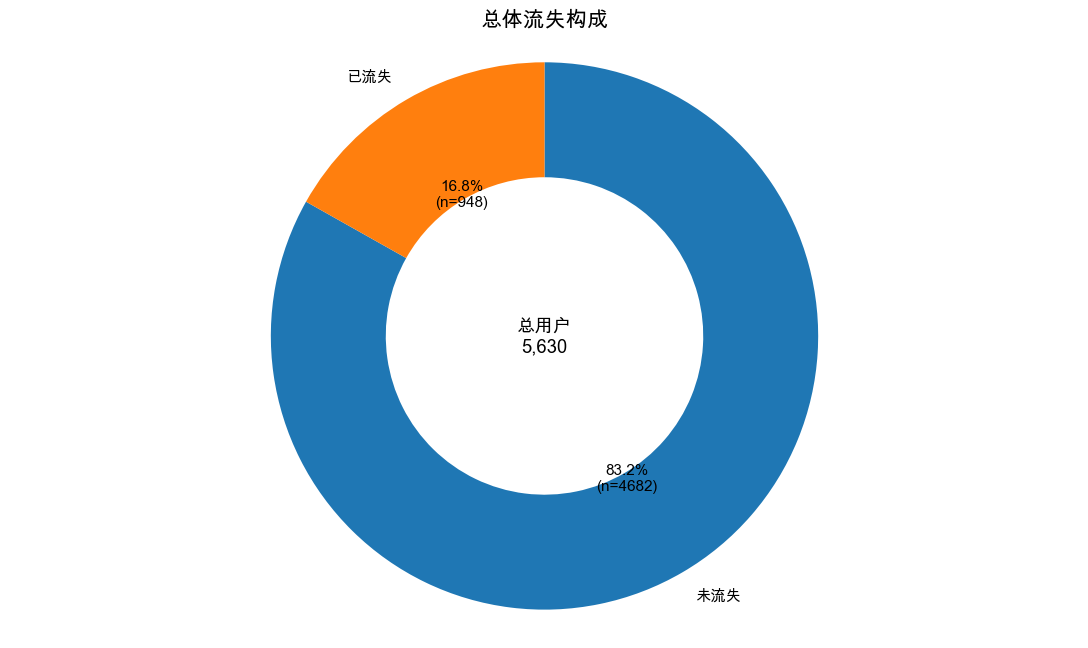

已输出： output/day06_visualization/04_composition_chart.png


In [14]:
def draw_composition(ax, compact=False):
    labels = composition_summary["流失状态"]
    counts = composition_summary["用户数"]
    total = int(counts.sum())

    ax.pie(
        counts,
        labels=labels,
        autopct=lambda pct: f"{pct:.1f}%\n(n={pct * total / 100:.0f})",
        startangle=90,
        counterclock=False,
        wedgeprops={"width": 0.42},
        textprops={"fontsize": 8 if compact else 10},
    )
    ax.text(
        0,
        0,
        f"总用户\n{total:,}",
        ha="center",
        va="center",
        fontsize=10 if compact else 12,
        fontweight="bold",
    )
    ax.set_title(
        "总体流失构成",
        fontsize=11 if compact else 14,
        fontweight="bold",
    )
    ax.axis("equal")


fig_composition, ax_composition = plt.subplots(figsize=(10, 6))
draw_composition(ax_composition)
fig_composition.tight_layout()

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_composition)

assert composition_path.exists() and composition_path.stat().st_size > 0
print("已输出：", composition_path.relative_to(ROOT))


In [15]:
composition_top = composition_summary.loc[composition_summary["占比"].idxmax()]
composition_other = composition_summary.loc[composition_summary["占比"].idxmin()]

display(Markdown(
    f"""
### 构成图结论

- **观察：** 当前样本以`{composition_top["流失状态"]}`用户为主。
- **证据：** `{composition_top["流失状态"]}`用户有
  {int(composition_top["用户数"]):,}人，占{composition_top["占比"]:.2%}；
  `{composition_other["流失状态"]}`用户有{int(composition_other["用户数"]):,}人，
  占{composition_other["占比"]:.2%}。
- **边界：** 环形图适合展示两个类别的整体构成，但不适合精细比较很多类别，
  也不能解释用户为什么流失；流失原因需要结合投诉、生命周期和行为字段分析。
"""
))



### 构成图结论

- **观察：** 当前样本以`未流失`用户为主。
- **证据：** `未流失`用户有
  4,682人，占83.16%；
  `已流失`用户有948人，
  占16.84%。
- **边界：** 环形图适合展示两个类别的整体构成，但不适合精细比较很多类别，
  也不能解释用户为什么流失；流失原因需要结合投诉、生命周期和行为字段分析。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [16]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


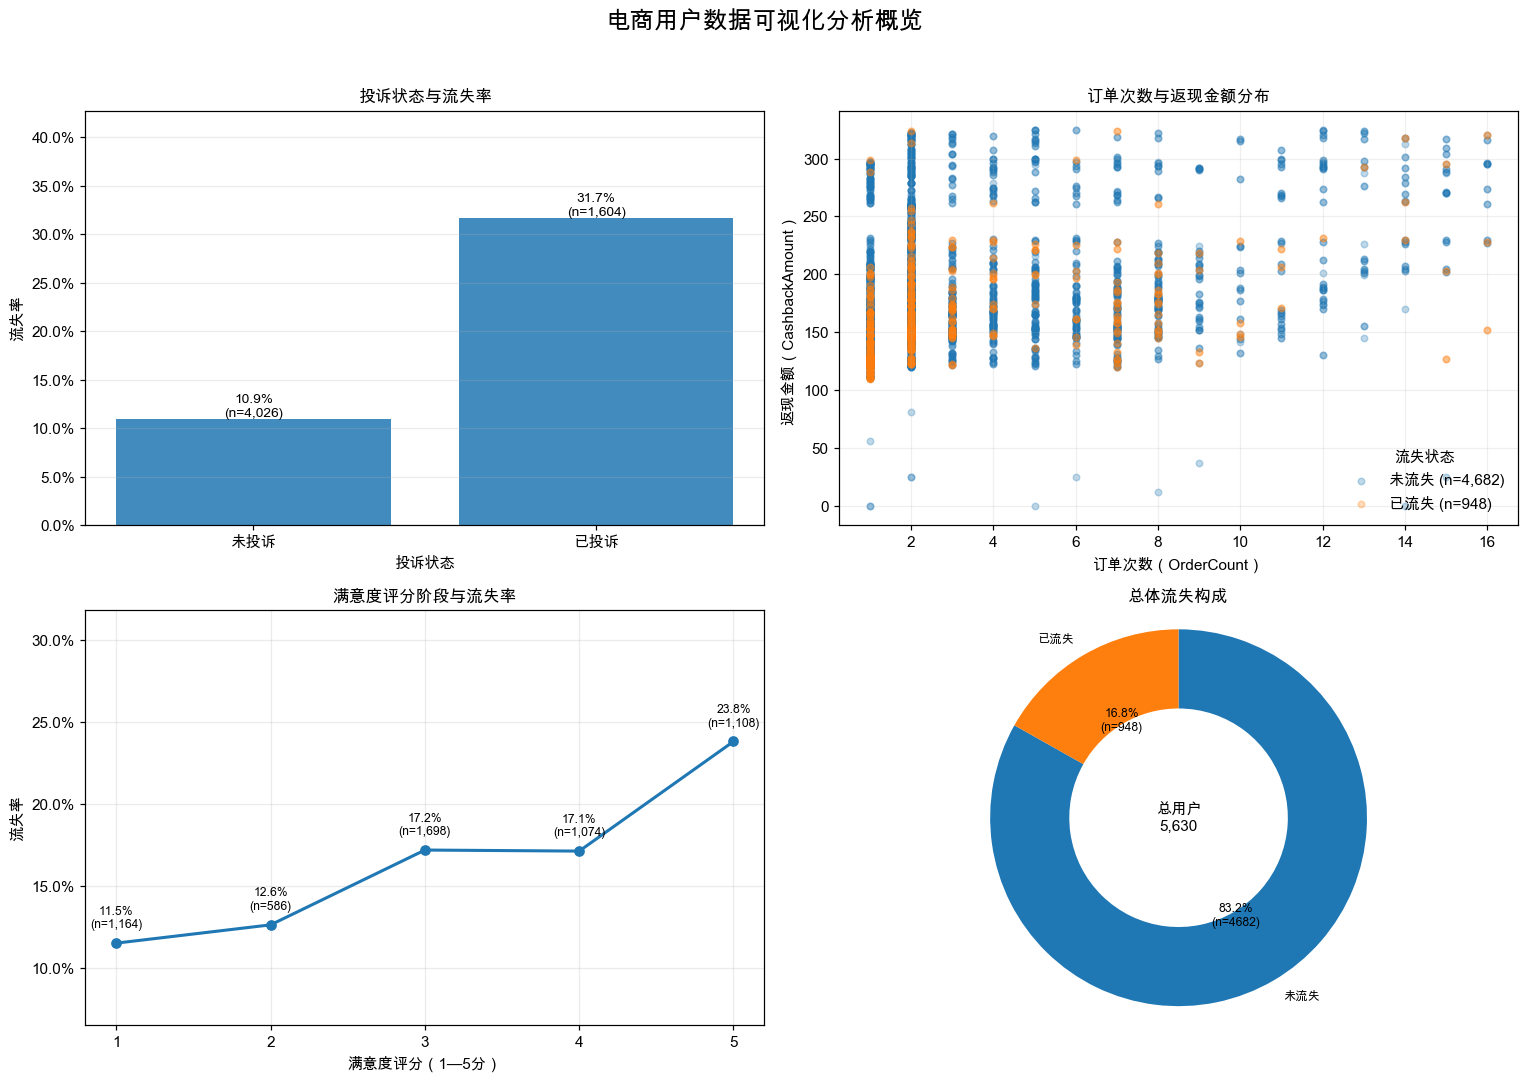

已输出： output/day06_visualization/day06_visualization_summary.png


In [17]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

draw_category_bar(axes[0, 0], compact=True)
draw_behavior_scatter(axes[0, 1], compact=True)
draw_ordered_line(axes[1, 0], compact=True)
draw_composition(axes[1, 1], compact=True)

fig_summary.suptitle(
    "电商用户数据可视化分析概览",
    fontsize=16,
    fontweight="bold",
)
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_summary)

assert summary_path.exists() and summary_path.stat().st_size > 0
print("已输出：", summary_path.relative_to(ROOT))


In [18]:
overall_churn_rate = float(df["Churn"].mean())

display(Markdown(
    f"""
## 综合发现与局限

1. **投诉状态分组差异：** `{bar_high["投诉状态"]}`组流失率为
   {bar_high["流失率"]:.2%}，`{bar_low["投诉状态"]}`组为
   {bar_low["流失率"]:.2%}，差异约{bar_gap * 100:.2f}个百分点；
   解释时必须同时关注两组样本量。
2. **满意度并非简单单调关系：** 满意度{int(line_high[ordered_field])}分组
   流失率最高（{line_high["流失率"]:.2%}），
   {int(line_low[ordered_field])}分组最低（{line_low["流失率"]:.2%}）。
3. **行为变量存在重叠：** 订单次数与返现金额相关系数为
   `r={scatter_corr:.3f}`，且流失/未流失散点大量重叠；
   仅凭这两个字段不宜直接判定流失。
4. **总体与局限：** 样本总体流失率为{overall_churn_rate:.2%}。
   当前分析为横截面描述，缺少订单日期、实际交易金额、投诉详情及干预记录，
   因此不能分析时间趋势、GMV，也不能把分组差异解释为确定因果关系。
"""
))



## 综合发现与局限

1. **投诉状态分组差异：** `已投诉`组流失率为
   31.67%，`未投诉`组为
   10.93%，差异约20.74个百分点；
   解释时必须同时关注两组样本量。
2. **满意度并非简单单调关系：** 满意度5分组
   流失率最高（23.83%），
   1分组最低（11.51%）。
3. **行为变量存在重叠：** 订单次数与返现金额相关系数为
   `r=0.322`，且流失/未流失散点大量重叠；
   仅凭这两个字段不宜直接判定流失。
4. **总体与局限：** 样本总体流失率为16.84%。
   当前分析为横截面描述，缺少订单日期、实际交易金额、投诉详情及干预记录，
   因此不能分析时间趋势、GMV，也不能把分组差异解释为确定因果关系。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [19]:
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": business_questions["category_bar"],
        "chart_type": "bar",
        "key_finding": (
            f'{bar_high["投诉状态"]}组流失率{bar_high["流失率"]:.2%}，'
            f'{bar_low["投诉状态"]}组{bar_low["流失率"]:.2%}，'
            f'相差{bar_gap * 100:.2f}个百分点。'
        ),
        "limitation": "分组差异只能说明关联，不能证明投诉直接导致流失。",
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": business_questions["behavior_scatter"],
        "chart_type": "scatter",
        "key_finding": (
            f"订单次数与返现金额相关系数r={scatter_corr:.3f}，"
            "两类用户分布存在较多重叠。"
        ),
        "limitation": "相关不等于因果，极端点只能作为候选异常进一步核查。",
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": business_questions["ordered_line"],
        "chart_type": "line",
        "key_finding": (
            f'满意度{int(line_high[ordered_field])}分组流失率最高'
            f'（{line_high["流失率"]:.2%}），'
            f'{int(line_low[ordered_field])}分组最低'
            f'（{line_low["流失率"]:.2%}）。'
        ),
        "limitation": "这是有序评分阶段比较，不是历史时间趋势。",
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": business_questions["composition_chart"],
        "chart_type": "donut",
        "key_finding": (
            f'{composition_top["流失状态"]}用户占'
            f'{composition_top["占比"]:.2%}，'
            f'{composition_other["流失状态"]}用户占'
            f'{composition_other["占比"]:.2%}。'
        ),
        "limitation": "构成图只能展示占比，不能解释流失原因。",
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "综合呈现投诉、行为、满意度阶段和总体流失构成。",
        "chart_type": "dashboard",
        "key_finding": (
            f"总体流失率{overall_churn_rate:.2%}；"
            "投诉状态与满意度阶段存在分组差异，"
            "行为散点分布仍有明显重叠。"
        ),
        "limitation": "横截面描述不能替代因果识别，也不能分析时间趋势。",
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(
    lambda col: col.str.contains("请填写").any()
).any()

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")

manifest_check = pd.read_csv(manifest_path)
assert manifest_check.shape == chart_manifest.shape
assert not any(str(col).startswith("Unnamed") for col in manifest_check.columns)

display(chart_manifest)
print("已输出：", manifest_path.relative_to(ROOT))


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,投诉用户与未投诉用户的流失率是否存在差异，各组样本量分别是多少？,bar,已投诉组流失率31.67%，未投诉组10.93%，相差20.74个百分点。,分组差异只能说明关联，不能证明投诉直接导致流失。
1,02,02_behavior_scatter.png,用户订单次数与返现金额之间呈现怎样的关系，流失用户和未流失用户的分布是否不同？,scatter,订单次数与返现金额相关系数r=0.322，两类用户分布存在较多重叠。,相关不等于因果，极端点只能作为候选异常进一步核查。
2,03,03_ordered_line.png,随着满意度评分从1分提高到5分，各评分阶段的流失率如何变化？,line,满意度5分组流失率最高（23.83%），1分组最低（11.51%）。,这是有序评分阶段比较，不是历史时间趋势。
3,04,04_composition_chart.png,当前样本中流失用户和未流失用户分别占多大比例？,donut,未流失用户占83.16%，已流失用户占16.84%。,构成图只能展示占比，不能解释流失原因。
4,05,day06_visualization_summary.png,综合呈现投诉、行为、满意度阶段和总体流失构成。,dashboard,总体流失率16.84%；投诉状态与满意度阶段存在分组差异，行为散点分布仍有明显重叠。,横截面描述不能替代因果识别，也不能分析时间趋势。


已输出： output/day06_visualization/chart_manifest.csv


In [20]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
